## Objective
1. Load pretrained BERT model
2. Fully finetune BERT model
3. Evaluate model performance on test data

In [20]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

Load the data

In [41]:
df_json = pd.read_json('Sarcasm_Headlines_Dataset.json', lines=True)
df_json = df_json.drop(columns=['article_link'])
print(df_json.shape)
print(df_json['is_sarcastic'].value_counts())
df_json.head(20)

(26709, 2)
is_sarcastic
0    14985
1    11724
Name: count, dtype: int64


,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0
5,advancing the world's women,0
6,the fascinating case for eating lab-grown meat,0
7,"this ceo will send your kids to school, if you...",0
8,top snake handler leaves sinking huckabee camp...,1
9,friday's morning email: inside trump's presser...,0


Split data into training, validation, and test sets.

In [27]:
train_df, test_df = train_test_split(df_json, test_size=0.2, random_state=42, stratify=df_json['is_sarcastic'])
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42, stratify=test_df['is_sarcastic'])

print(f"Training set size: {len(train_df)} samples")
print(f"Validation set size: {len(val_df)} samples")
print(f"Test set size: {len(test_df)} samples")

Training set size: 21367 samples
Validation set size: 2671 samples
Test set size: 2671 samples


Load pretrained BERT model

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenize the data

In [29]:
def tokenize_function(text):
    return tokenizer(text["headline"], padding="max_length", truncation=True)

# Convert pandas DataFrames to Dataset objects and rename 'is_sarcastic' to 'labels'
train_df = Dataset.from_pandas(train_df.rename(columns={'is_sarcastic': 'labels'}))
val_df = Dataset.from_pandas(val_df.rename(columns={'is_sarcastic': 'labels'}))
test_df = Dataset.from_pandas(test_df.rename(columns={'is_sarcastic': 'labels'}))

tokenized_train_df = train_df.map(tokenize_function, batched=True)
tokenized_val_df = val_df.map(tokenize_function, batched=True)
tokenized_test_df = test_df.map(tokenize_function, batched=True)


Map:   0%|          | 0/21367 [00:00<?, ? examples/s]

Map:   0%|          | 0/2671 [00:00<?, ? examples/s]

Map:   0%|          | 0/2671 [00:00<?, ? examples/s]

Define metrics

In [21]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

Train the model

In [32]:
model_name = "full-finetuned-bert-sarcasm"

# Define hyperaparameters
best_learning_rate = 2.3089e-5
best_batch_size = 16
best_weight_decay = 0.0074117

# Define training arguments
training_args = TrainingArguments(
    output_dir=model_name,
    eval_strategy="epoch",
    learning_rate=best_learning_rate,
    per_device_train_batch_size=best_batch_size,
    per_device_eval_batch_size=best_batch_size,
    num_train_epochs=1,
    weight_decay=best_weight_decay,
    fp16=True,
    save_strategy="epoch",
    disable_tqdm=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_train_df,
    eval_dataset=tokenized_val_df
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.241000,0.195005,0.921378,0.921148,0.921688,0.921378


TrainOutput(global_step=1336, training_loss=0.2606136813135204, metrics={'train_runtime': 552.4433, 'train_samples_per_second': 38.677, 'train_steps_per_second': 2.418, 'total_flos': 5621893919877120.0, 'train_loss': 0.2606136813135204, 'epoch': 1.0})

Evaluate model on test data

In [33]:
# Evaluate on test data
preds_outputs = trainer.predict(tokenized_test_df)
preds_outputs.metrics

{'test_loss': 0.17804180085659027,
 'test_accuracy': 0.9318607263197305,
 'test_f1': 0.9315131839997338,
 'test_precision': 0.9331596995463093,
 'test_recall': 0.9318607263197305,
 'test_runtime': 21.883,
 'test_samples_per_second': 122.058,
 'test_steps_per_second': 7.631}

               precision    recall  f1-score   support

not sarcastic       0.92      0.97      0.94      1499
    sarcastic       0.96      0.89      0.92      1172

     accuracy                           0.93      2671
    macro avg       0.94      0.93      0.93      2671
 weighted avg       0.93      0.93      0.93      2671



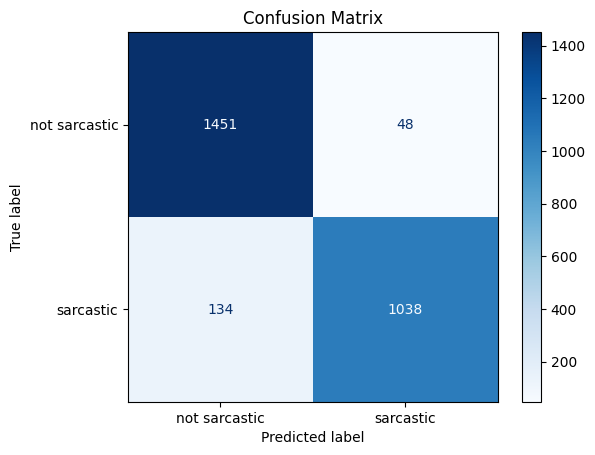

In [40]:
id_to_label_map = {0: "not sarcastic", 1: "sarcastic"}
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = [label for label in tokenized_test_df["labels"]]
print(classification_report(y_true, y_preds, zero_division=0, target_names=id_to_label_map.values()))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id_to_label_map.values()))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Save the model

In [50]:
!pip install huggingface_hub --quiet

In [51]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# This will create a public repository under your username.
REPO_ID = "full-finetuned-bert-for-sarcasm-detection"

# Push the model and tokenizer to the Hub
model.push_to_hub(REPO_ID, commit_message="Full-finetuned bert model")
tokenizer.push_to_hub(REPO_ID)